# Statistical Analysis

## Target Variable

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df = pd.read_csv('../data/clean/processed_data.csv')

In [33]:
df['dependency_score'] = df[['ai_emotional_support_perception', 'ai_vs_human_interaction', 'ai_discomfort', 'ai_decision_support', 'ai_understanding',
                             'ai_vs_human_trust']].mean(axis=1)
bins = [1,2.5,4,5]
labels =['low', 'medium', 'high']
df['dependency_level'] = pd.cut(df['dependency_score'], bins=bins, labels=labels, include_lowest=True)
df.sample(5)

,age,career,ai_hours,ai_usage_frequency,ai_usage_type,ai_emotional_support_perception,ai_vs_human_interaction,ai_discomfort,ai_decision_support,ai_understanding,ai_vs_human_trust,social_interaction_frequency,seeks_help_from_others,uses_ai_for_emotional_support,follows_ai_advice,dependency_score,dependency_level
127,18-21,Ingeniería / STEM,1–2 horas,Varias veces al día,Estudio / tareas académicas,1,1,2,1,1,3,Frecuentemente,"Personas (amigos, familia)",False,False,1.500000,low
54,18-21,Ingeniería / STEM,Menos de 1 hora,Algunas veces a la semana,Estudio / tareas académicas,1,1,1,1,3,1,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.333333,low
22,18-21,Ingeniería / STEM,Menos de 1 hora,Algunas veces a la semana,Estudio / tareas académicas,2,2,1,1,2,2,Frecuentemente,Ambos por igual,False,True,1.666667,low
25,18-21,Ciencias Sociales / Humanidades,Menos de 1 hora,Algunas veces a la semana,Estudio / tareas académicas,1,1,2,1,1,1,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.166667,low
51,18-21,Ingeniería / STEM,Menos de 1 hora,Varias veces al día,Estudio / tareas académicas,2,5,1,4,2,5,Muy frecuentemente,"Personas (amigos, familia)",True,False,3.166667,medium


Text(0, 0.5, 'Score')

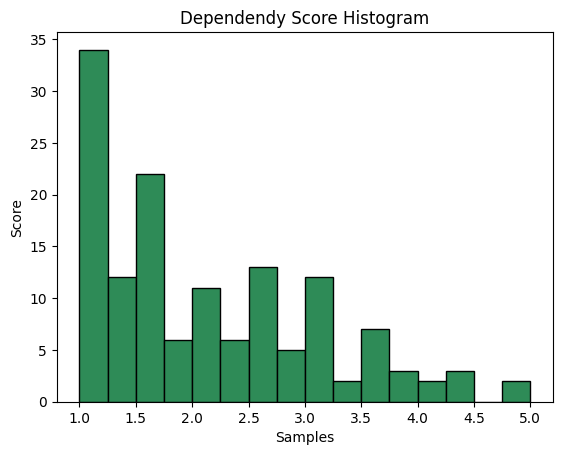

In [34]:
plt.hist(df['dependency_score'], bins=16, color='seagreen', edgecolor='black')
plt.title("Dependendy Score Histogram")
plt.xlabel("Samples")
plt.ylabel("Score")

In [35]:
df['dependency_level'].value_counts()

dependency_level
low       99
medium    34
high       7
Name: count, dtype: int64

## Confidence interval for the Mean Dependency Score


In [55]:
from scipy import stats

data = df["dependency_score"]

n = len(data)
mean = np.mean(data)
std = np.std(data, ddof=1)

confidence = 0.95
alpha = 1 - confidence

t_crit = stats.t.ppf(1 - alpha/2, df=n-1)

se = std / np.sqrt(n)

ci_lower = mean - t_crit * se
ci_upper = mean + t_crit * se

mean, ci_lower, ci_upper

(np.float64(2.0952380952380953),
 np.float64(1.929506065234399),
 np.float64(2.2609701252417915))

## T-test

## Hypothesis Testing (t-test)

We analyze whether there is a difference in dependency scores between usage groups.

### Null Hypothesis (H₀):

$$
H_0: \mu_{low} = \mu_{high}
$$

### Alternative Hypothesis (H₁):

$$
H_1: \mu_{high} > \mu_{low}
$$

### Test Statistic

The t-statistic for two independent samples is defined as:

$$
t = \frac{\bar{X}_{high} - \bar{X}_{low}}{\sqrt{\frac{s_{high}^2}{n_{high}} + \frac{s_{low}^2}{n_{low}}}}
$$
Where:
- $(\bar{X}_{high}, \bar{X}_{low}$): sample means  
- $(s^2$): sample variances  
- $(n$): sample sizes

In [36]:
df['high_usage'] = df['ai_hours'].isin([
    '2–4 horas',
    'Más de 4 horas'
]).astype(int)
df['high_usage'].value_counts()

high_usage
0    109
1     31
Name: count, dtype: int64

In [37]:
df.sample(10)

,age,career,ai_hours,ai_usage_frequency,ai_usage_type,ai_emotional_support_perception,ai_vs_human_interaction,ai_discomfort,ai_decision_support,ai_understanding,ai_vs_human_trust,social_interaction_frequency,seeks_help_from_others,uses_ai_for_emotional_support,follows_ai_advice,dependency_score,dependency_level,high_usage
106,18-21,Ingeniería / STEM,2–4 horas,Varias veces al día,Estudio / tareas académicas,3,1,3,2,2,1,Rara vez,Ambos por igual,True,True,2.000000,low,1
63,18-21,Ingeniería / STEM,Menos de 1 hora,Algunas veces a la semana,Estudio / tareas académicas,1,1,1,1,1,1,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.000000,low,0
34,Menos de 18,Otro,Más de 4 horas,Rara vez,Entretenimiento,4,3,2,1,2,1,Ocasionalmente,Ambos por igual,True,False,2.166667,low,1
129,22-24,Ingeniería / STEM,1–2 horas,Una vez al día,Estudio / tareas académicas,2,1,1,1,2,1,Frecuentemente,"Personas (amigos, familia)",True,False,1.333333,low,0
109,+25,Ciencias Sociales / Humanidades,Menos de 1 hora,Algunas veces a la semana,Entretenimiento,3,3,3,1,3,1,Muy frecuentemente,"Personas (amigos, familia)",False,False,2.333333,low,0
50,18-21,Ingeniería / STEM,2–4 horas,Varias veces al día,Estudio / tareas académicas,3,1,2,1,1,1,Muy frecuentemente,"Personas (amigos, familia)",True,True,1.500000,low,1
39,18-21,Ingeniería / STEM,1–2 horas,Varias veces al día,Estudio / tareas académicas,2,2,2,3,2,2,Muy frecuentemente,Ambos por igual,True,False,2.166667,low,0
60,+25,Ciencias Sociales / Humanidades,Menos de 1 hora,Algunas veces a la semana,Trabajo,1,1,1,1,1,1,Muy frecuentemente,"Personas (amigos, familia)",True,False,1.000000,low,0
113,+25,Ciencias Sociales / Humanidades,Menos de 1 hora,Rara vez,Entretenimiento,1,1,1,1,1,1,Frecuentemente,"Personas (amigos, familia)",False,False,1.000000,low,0
48,+25,Otro,1–2 horas,Varias veces al día,Apoyo emocional / personal,5,5,4,5,5,5,Muy frecuentemente,IA,True,True,4.833333,high,0


In [38]:
group_high = df[df['high_usage'] == 1]['dependency_score']
group_low  = df[df['high_usage'] == 0]['dependency_score']

In [39]:
n1 = len(group_high)
n2 = len(group_low)
mean1 = group_high.mean()
mean2 = group_low.mean()
var1 = group_high.var(ddof=1)
var2 = group_low.var(ddof=1)

In [40]:
se = np.sqrt((var1 / n1) + (var2 / n2))

In [41]:
t_stat = (mean1 - mean2) / se
df_num = (var1/n1 + var2/n2)**2
df_den = ((var1/n1)**2)/(n1-1) + ((var2/n2)**2)/(n2-1)
df_t = df_num / df_den
t_stat

np.float64(2.832136127827554)

In [42]:
from scipy.stats import t

p_value = 1 - t.cdf(t_stat, df_t)
p_value

np.float64(0.003488829305746677)

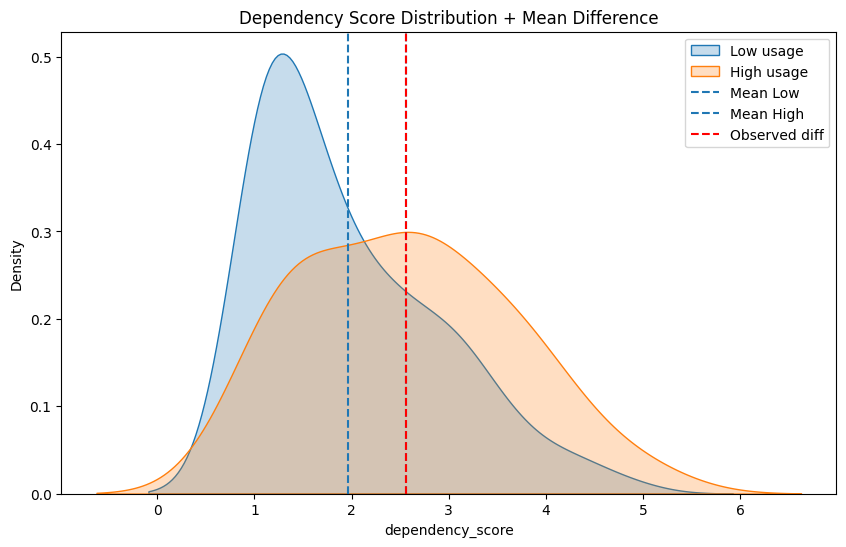

In [52]:
plt.figure(figsize=(10,6))

sns.kdeplot(group_low, fill=True, label="Low usage")
sns.kdeplot(group_high, fill=True, label="High usage")

# mark means
plt.axvline(group_low.mean(), linestyle="--", label="Mean Low")
plt.axvline(group_high.mean(), linestyle="--", label="Mean High")

# show observed difference
plt.axvline(group_low.mean() + (mean1-mean2), color="red", linestyle="--", label="Observed diff")

plt.title("Dependency Score Distribution + Mean Difference")
plt.legend()
plt.savefig("../paper/t_test_distribution.png", bbox_inches="tight")
plt.show()

### Conclusion (t-test)

The independent samples t-test revealed a statistically significant difference in mean AI dependency scores between low-usage and high-usage groups (p = 0.003). Therefore, we reject the null hypothesis and conclude that higher AI usage is associated with significantly higher levels of dependency.

## Chi-squared test

We analyze whether there is a relationship between in-person social interaction frequency and AI dependency level.

### Null Hypothesis (H₀):

In-person interaction and AI dependency are independent.

$$
H_0: P(X, Y) = P(X)P(Y)
$$

or equivalently:

$$
H_0: \text{Social Interaction} \perp \text{AI Dependency}
$$

---

### Alternative Hypothesis (H₁):

There is an association between in-person interaction and AI dependency.

$$
H_1: \text{Social Interaction} \not\perp \text{AI Dependency}
$$

### Chi-Squared Statistic

The chi-squared statistic is computed as:

$$
\chi^2 = \sum \frac{(O - E)^2}{E}
$$

Where:
- \(O\): observed frequencies  
- \(E\): expected frequencies under independence

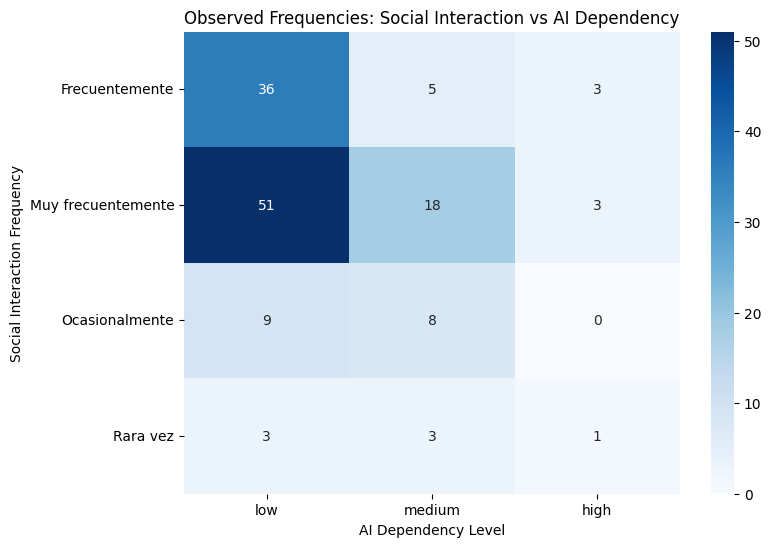

In [53]:
table = pd.crosstab(
    df['social_interaction_frequency'],
    df['dependency_level']
)

plt.figure(figsize=(8,6))
sns.heatmap(table, annot=True, fmt="d", cmap="Blues")

plt.title("Observed Frequencies: Social Interaction vs AI Dependency")
plt.xlabel("AI Dependency Level")
plt.ylabel("Social Interaction Frequency")
plt.savefig("../paper/chi_squared_heatmap.png", bbox_inches="tight")
plt.show()


In [44]:
# observed table
observed = table.values

# totals
row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)
N = observed.sum()

# expected table
expected = np.outer(row_totals, col_totals) / N

# chi-square statistic
chi2_stat = ((observed - expected)**2 / expected).sum()

print("Chi2:", chi2_stat)

Chi2: 12.407784536598628


In [45]:
r, c = observed.shape
chi_df = (r - 1) * (c - 1)

print("Degrees of freedom:", chi_df)

Degrees of freedom: 6


In [46]:
from scipy.stats import chi2

p_value = 1 - chi2.cdf(chi2_stat, chi_df)

print("p-value:", p_value)

p-value: 0.05346593692583379


In [47]:
df.to_csv('../data/clean/target_data.csv', index=0)

### Conclusion (Chi-squared test)

The chi-squared test of independence showed a marginal result (p = 0.053), which is slightly above the conventional significance threshold of 0.05. Therefore, we fail to reject the null hypothesis at the 5% significance level. However, the results suggest a weak association between in-person social interaction frequency and AI dependency, indicating a possible relationship that may require a larger sample size or further investigation.